In [59]:
import pandas as pd

ratings = pd.read_csv(
    "ml-1m/ratings.dat",
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

movies = pd.read_csv(
    "ml-1m/movies.dat",
    sep="::",
    engine="python",
    encoding="latin1",
    names=["movie_id", "title", "genres"]
)

users = pd.read_csv(
    "ml-1m/users.dat",
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zipcode"]
)

print(ratings.head())

   user_id  movie_id  rating  timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968
3        1      3408       4  978300275
4        1      2355       5  978824291


In [35]:
print(users.head())

   user_id gender  age  occupation zipcode
0        1      F    1          10   48067
1        2      M   56          16   70072
2        3      M   25          15   55117
3        4      M   45           7   02460
4        5      M   25          20   55455


In [60]:
data = ratings.merge(users, on="user_id")

print(data.head())

   user_id  movie_id  rating  timestamp gender  age  occupation zipcode
0        1      1193       5  978300760      F    1          10   48067
1        1       661       3  978302109      F    1          10   48067
2        1       914       3  978301968      F    1          10   48067
3        1      3408       4  978300275      F    1          10   48067
4        1      2355       5  978824291      F    1          10   48067


In [61]:
data["gender"] = data["gender"].map({
    "M": 1,
    "F": 0
})

In [39]:
X = data[
    ["user_id",
     "movie_id",
     "gender",
     "age",
     "occupation"]
]

y = data["rating"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
data.head()


,user_id,movie_id,rating,timestamp,gender,age,occupation,zipcode
0,1,1193,5,978300760,0,1,10,48067
1,1,661,3,978302109,0,1,10,48067
2,1,914,3,978301968,0,1,10,48067
3,1,3408,4,978300275,0,1,10,48067
4,1,2355,5,978824291,0,1,10,48067


In [24]:
print(X.isnull().sum())

user_id       0
movie_id      0
gender        0
age           0
occupation    0
dtype: int64


In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[3.50537839 3.7751584  3.39754191 3.54138905 3.54504775 3.6030416
 3.75687564 3.53660843 3.54884844 3.66910038]


In [44]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE =", rmse)
print("R² =", r2)

RMSE = 1.1155169945735581
R² = 0.007508788083219087


In [45]:
print("Intercept:", model.intercept_)

for feature, coef in zip(X.columns, model.coef_):
    print(feature, coef)

Intercept: 3.554590651044399
user_id 5.731136323624288e-06
movie_id -6.714328581692804e-05
gender -0.04764406391422812
age 0.005522314461968087
occupation 0.0007918720296492685


## The Learned Model

The learned model is:

$$
\text{rating}
=
b
+
w_1(\text{user\_id})
+
w_2(\text{movie\_id})
+
w_3(\text{gender})
+
w_4(\text{age})
+
w_5(\text{occupation})
$$

where \( b \) and the \( w_i \) values are learned from the MovieLens data.

Ecample->

Given weights and bias calculate the rating?

Intercept = 3.25

user_id      0.0002
movie_id    -0.0001
gender       0.15
age          0.01
occupation  -0.02

Ans ->
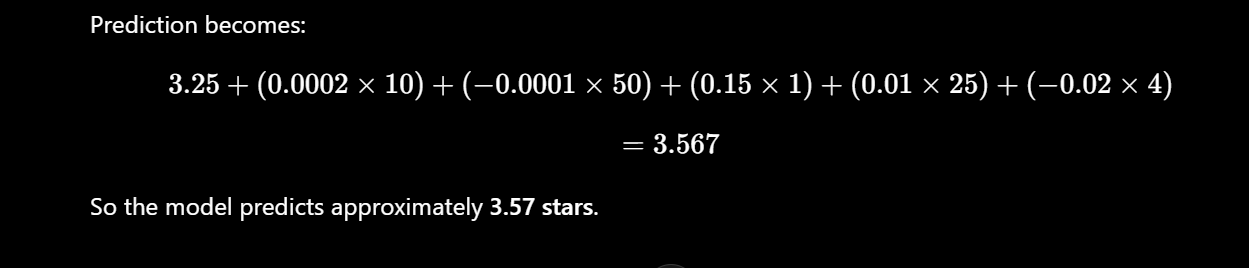

NOW, Trying to Understand witht the Plots...


In [47]:
print(data.shape)
print(data.info())


(1000209, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 8 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   user_id     1000209 non-null  int64 
 1   movie_id    1000209 non-null  int64 
 2   rating      1000209 non-null  int64 
 3   timestamp   1000209 non-null  int64 
 4   gender      1000209 non-null  int64 
 5   age         1000209 non-null  int64 
 6   occupation  1000209 non-null  int64 
 7   zipcode     1000209 non-null  object
dtypes: int64(7), object(1)
memory usage: 61.0+ MB
None


In [48]:
print(data.describe())

            user_id      movie_id        rating     timestamp        gender  \
count  1.000209e+06  1.000209e+06  1.000209e+06  1.000209e+06  1.000209e+06   
mean   3.024512e+03  1.865540e+03  3.581564e+00  9.722437e+08  7.536115e-01   
std    1.728413e+03  1.096041e+03  1.117102e+00  1.215256e+07  4.309076e-01   
min    1.000000e+00  1.000000e+00  1.000000e+00  9.567039e+08  0.000000e+00   
25%    1.506000e+03  1.030000e+03  3.000000e+00  9.653026e+08  1.000000e+00   
50%    3.070000e+03  1.835000e+03  4.000000e+00  9.730180e+08  1.000000e+00   
75%    4.476000e+03  2.770000e+03  4.000000e+00  9.752209e+08  1.000000e+00   
max    6.040000e+03  3.952000e+03  5.000000e+00  1.046455e+09  1.000000e+00   

                age    occupation  
count  1.000209e+06  1.000209e+06  
mean   2.973831e+01  8.036138e+00  
std    1.175198e+01  6.531336e+00  
min    1.000000e+00  0.000000e+00  
25%    2.500000e+01  2.000000e+00  
50%    2.500000e+01  7.000000e+00  
75%    3.500000e+01  1.400000e+01  


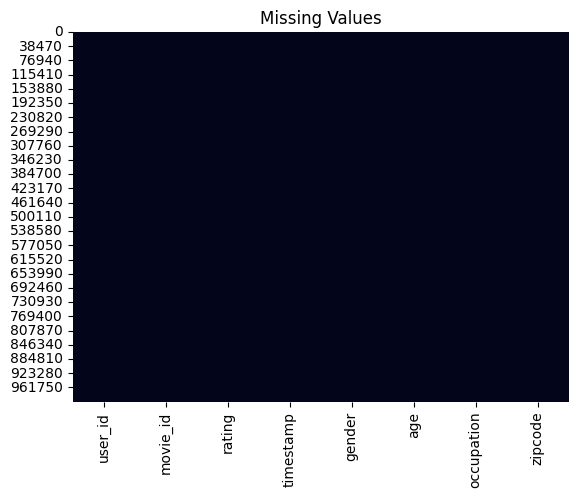

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

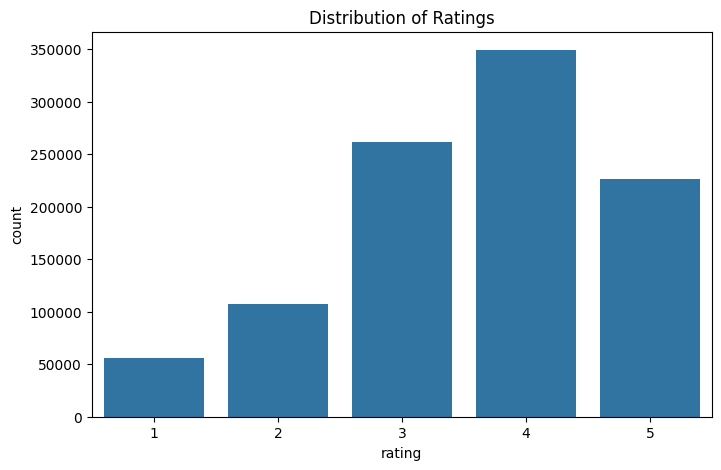

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(x='rating', data=data)

plt.title("Distribution of Ratings")
plt.show()

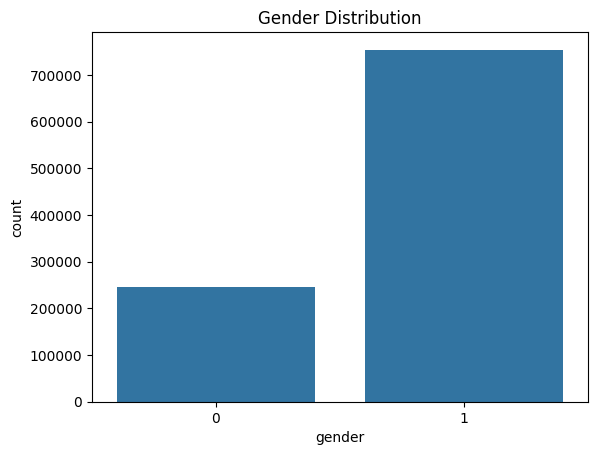

In [51]:
sns.countplot(x='gender', data=data)

plt.title("Gender Distribution")
plt.show()

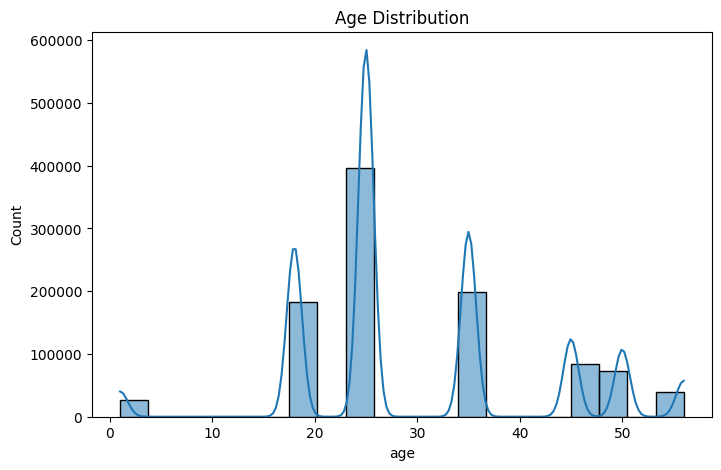

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(data['age'],
             bins=20,
             kde=True)

plt.title("Age Distribution")
plt.show()

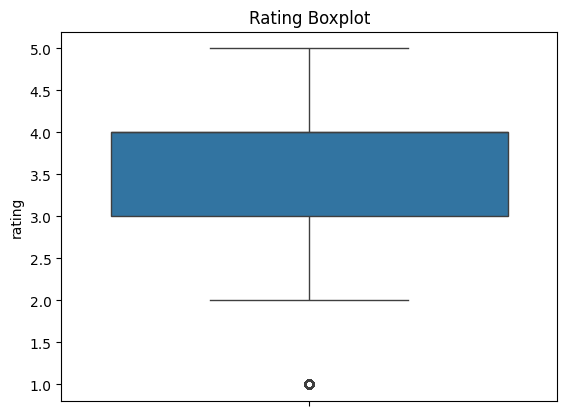

In [53]:
sns.boxplot(y=data['rating'])

plt.title("Rating Boxplot")
plt.show()

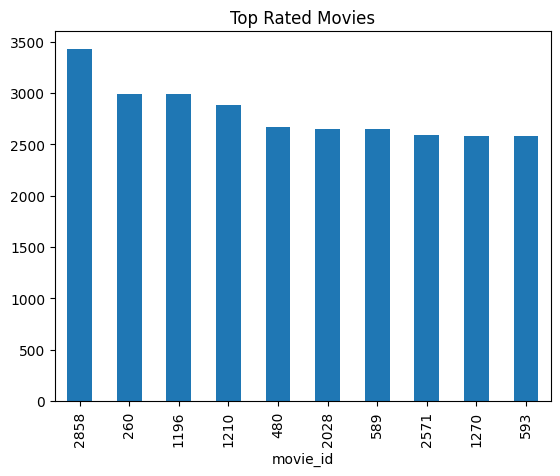

In [54]:
movie_count = data.groupby(
    'movie_id'
)['rating'].count()

top10 = movie_count.sort_values(
    ascending=False
).head(10)

top10.plot(kind='bar')

plt.title("Top Rated Movies")
plt.show()

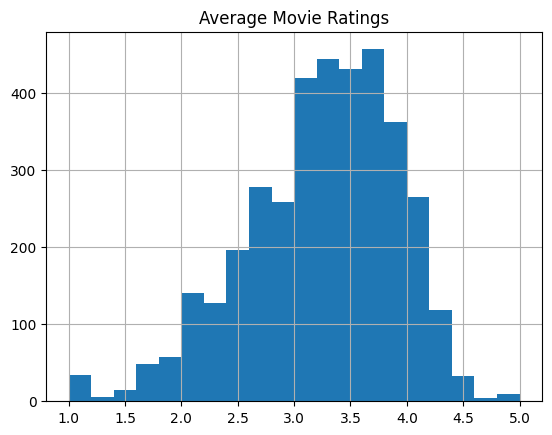

In [55]:
avg_rating = data.groupby(
    'movie_id'
)['rating'].mean()

avg_rating.hist(bins=20)

plt.title("Average Movie Ratings")
plt.show()

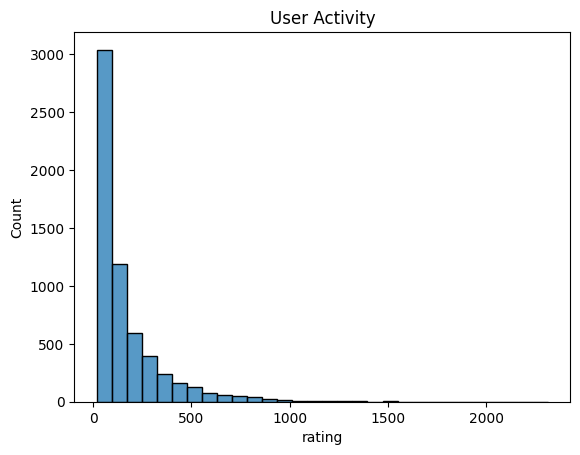

In [56]:
user_activity = data.groupby(
    'user_id'
)['rating'].count()

sns.histplot(user_activity,
             bins=30)

plt.title("User Activity")
plt.show()

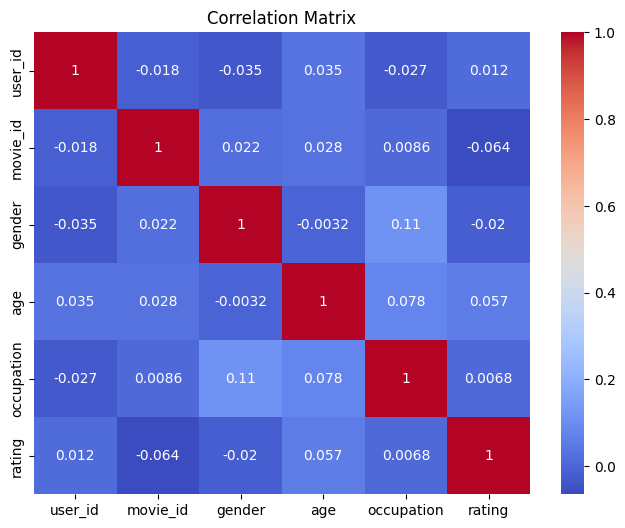

In [62]:
corr = data[
    ['user_id',
     'movie_id',
     'gender',
     'age',
     'occupation',
     'rating']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

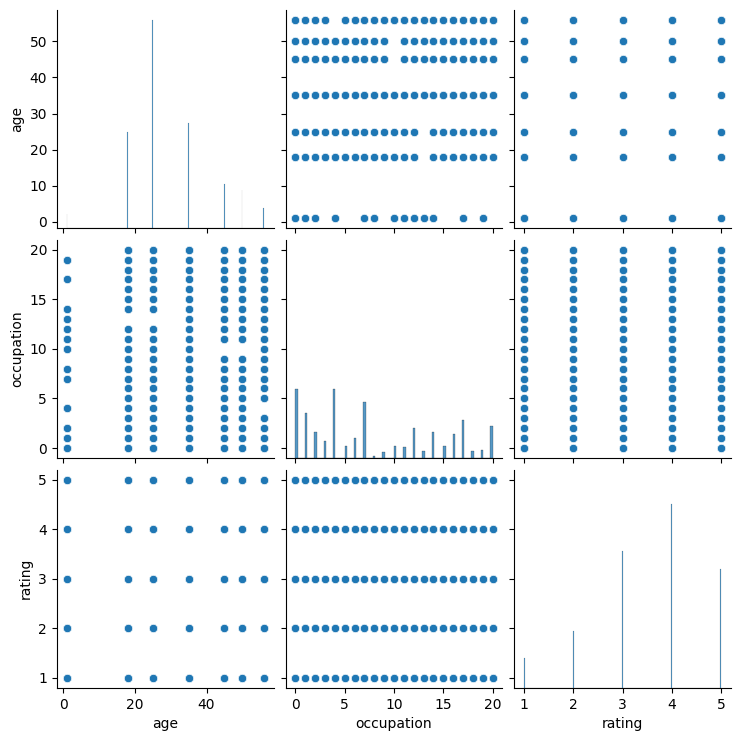

In [63]:
sns.pairplot(
    data[
        ['age',
         'occupation',
         'rating']
    ]
)

plt.show()

In [65]:
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

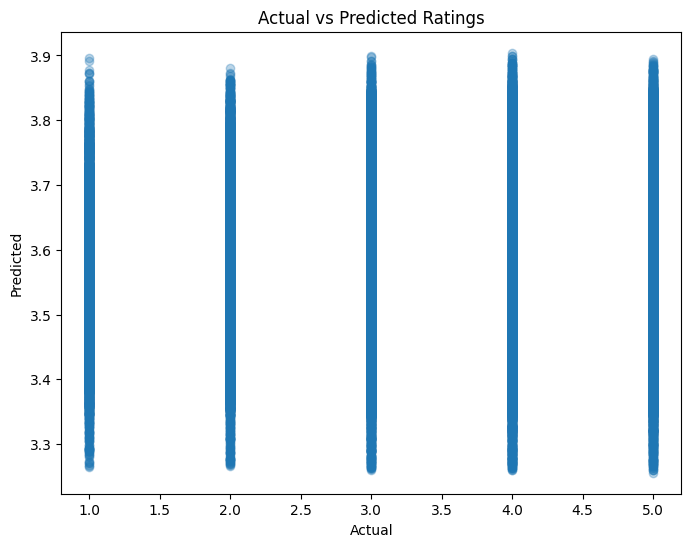

In [66]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted Ratings"
)

plt.show()

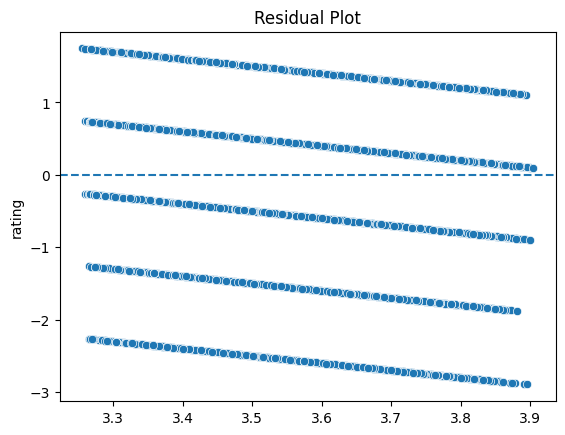

In [67]:
residuals = y_test - y_pred

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Residual Plot")

plt.show()

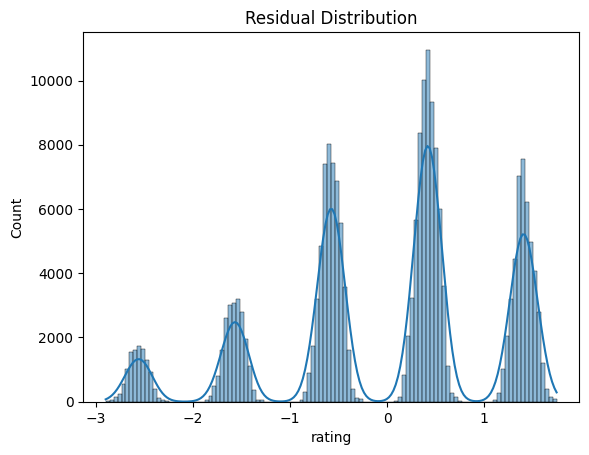

In [68]:
sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

In [69]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = mse**0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.929271082898595
MSE : 1.2443781651824235
RMSE: 1.1155169945735581
R2  : 0.007508788083219087


      Feature  Coefficient
0     user_id     0.000006
1    movie_id    -0.000067
2      gender    -0.047644
3         age     0.005522
4  occupation     0.000792


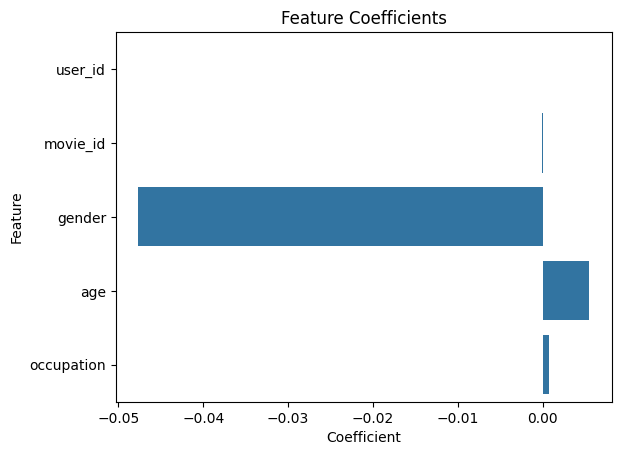

In [70]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coef_df)

sns.barplot(
    data=coef_df,
    x='Coefficient',
    y='Feature'
)

plt.title(
    "Feature Coefficients"
)

plt.show()